Author: @Bahae-Eddine Madir

# PINNs - Energy formulation

In [1]:
import sys
import os
sys.path.insert(1, './Utilities/')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [3]:
from matplotlib.patches import Rectangle

In [4]:
from AutoDiff import AG_grad

In [5]:
case = 'Ritz'
savedir = './outputs_' + case + '/'
os.makedirs(savedir, exist_ok=True)
save = True

In [6]:
# A (simple) feed forward N.N.
torch.manual_seed(1234)
class ff(torch.nn.Module):
    def __init__(self, n_neurones):
        super().__init__()
        self.l1 = torch.nn.Linear(2, n_neurones)
        self.act = torch.nn.Tanh()
        self.l2 = torch.nn.Linear(n_neurones, 1)
        self.params_dict = dict(self.named_parameters())
    def forward(self, *inputs):
        inputs = torch.cat(inputs, 1)
        outputs = self.act(self.l1(inputs))
        return self.l2(outputs)

device = torch.device("cpu")
net = ff(15).to(device)

In [7]:
# strong BC
model = lambda x, y: x* (x-1)* y* (y-1)* net(x, y)

In [8]:
# Manufactured Solution
u_ref = lambda x, y: torch.sin(torch.pi* x)* torch.sin(torch.pi* y) + (1/2)* torch.sin(3* torch.pi* x)* torch.sin(2* torch.pi* y)
f = lambda x, y: torch.pi**2* (2* torch.sin(torch.pi* x) + 13* torch.sin(3* torch.pi* x)* torch.cos(torch.pi* y))* torch.sin(torch.pi* y)

## Elements

In [9]:
def elements_fn(x, y):
    nx = len(x)
    ny = len(y)
    elements = []
    
    for i in range(nx):
        if x[i:i+2].numel()<2:
            continue
        for j in range(ny):
            if y[j:j+2].numel()<2:
                continue
            else:
                element = [x[i:i+2], y[j:j+2]]
                elements.append(element)

    return elements

In [10]:
nx = 4
ny = 4
x = torch.linspace(0, 1, nx+1).to(device)
y = torch.linspace(0, 1, ny+1).to(device)
elements = elements_fn(x, y)

## Integration

In [11]:
# from I_hat to I:
def scale_1D(x, I):
    A = (I[-1] - I[0])/2
    B = (I[-1] + I[0])/2
    return A * x + B, A

# from I to I_hat:
def inv_scale_1D(x):
    A = (x[-1] - x[0])/2
    B = (x[-1] + x[0])/2
    return (x - B)/A
    
# from K_hat to K
def scale(x, y, K):
    x, Jx = scale_1D(x, K[0])
    y, Jy = scale_1D(y, K[1])
    return x, y, Jx, Jy

In [12]:
# Quadrature:
from quadrature import GaussLegendre

q_ord = 10
(x_q, y_q), w_q = GaussLegendre().Quad2d(q_ord)

x_q = torch.Tensor(x_q).flatten()
y_q = torch.Tensor(y_q).flatten()
w_q = torch.Tensor(w_q)

In [13]:
quad = w_q.to(device), x_q.reshape(-1, 1).to(device), y_q.reshape(-1, 1).to(device)

In [14]:
def int_K(K, quad, f=lambda *args: torch.zeros_like(args[0])):
    """
    the test_fn are computed in K_hat. If test_fn.shape is (n, m) then grad_test_fn.shape is (n, 2, m)
    """
    # quadrature weights and nodes
    w, x, y = quad
    qx, qy = w.shape # order
    
    # scale x, y to K, and compute the Jacobien and rescale the gradient
    x, y, Jx, Jy = scale(x, y, K)
    J = Jx* Jy
    
    # compute grad_u = (u_x, u_y)
    if not x.requires_grad:
        x.requires_grad_()
    if not y.requires_grad:
        y.requires_grad_()
    
    u = model(x, y)
    grad_u = torch.stack(AG_grad(u, (x, y))).reshape(2, -1)
    _integrand = 0.5* (grad_u**2).sum(0) - f(x, y).flatten() * u.flatten()
    _int = torch.einsum('ji, ij->', w, J *_integrand.reshape(qx, qy))
    
    return _int

## Losses

In [15]:
def res_loss():
    loss = 0.
    for K in elements:
        _int = int_K(K, quad, f) 
        loss += _int
    return loss

In [16]:
def err_l2(ref, pred):
    return np.linalg.norm(ref - pred, 2) / np.linalg.norm(ref, 2)

## Optimization

In [17]:
losses = {'data':[], 'physics':[], 'total':[], 'l2':[]}

def closure():
    global l_data, l_phys
    net.zero_grad()
    l_phys = res_loss()
    loss = l_phys # + w_b * l_data
    
    loss.backward()
    
    return loss

In [18]:
optim = torch.optim.LBFGS(
    net.parameters(), 
    line_search_fn="strong_wolfe"
)
n_epochs = 26

In [19]:
nx = 100
x = torch.linspace(0, 1, nx).to(device)
x, y = torch.meshgrid(x, x, indexing="xy")
pred = model(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(nx, nx).cpu()
x = x.cpu()
y = y.cpu()

ref = u_ref(x, y)

In [20]:
%%time

for _ in tqdm(range(n_epochs)) :
    
    loss = optim.step(closure)
    
    # save
    #losses['data'].append(l_data.item())
    losses['physics'].append(l_phys.item())
    losses['total'].append(loss.item())

    pred = model(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(nx, nx).cpu()
    losses['l2'].append(err_l2(ref, pred))

  0%|          | 0/26 [00:00<?, ?it/s]

CPU times: user 51.8 s, sys: 28.6 ms, total: 51.8 s
Wall time: 5.85 s


## Pred

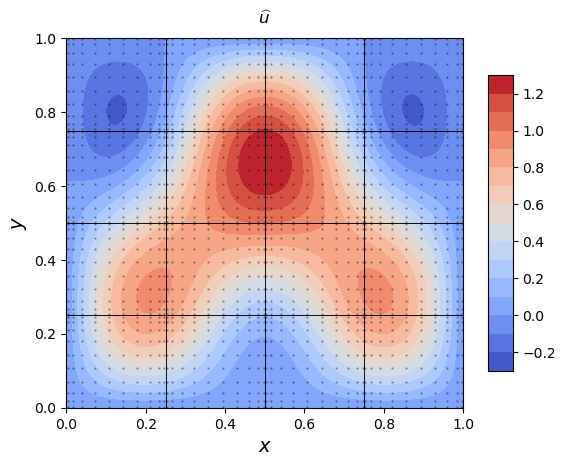

In [21]:
# pred
fig, ax = plt.subplots(1, 1)

cb = ax.contourf(x, y, pred, cmap='coolwarm', levels=15)
fig.colorbar(cb, shrink=.8, aspect=12)

for e in elements:
    mi_x, mi_y = min(e[0].cpu()), min(e[1].cpu())
    ma_x, ma_y = max(e[0].cpu()), max(e[1].cpu())
    ax.add_patch(Rectangle((mi_x, mi_y), ma_x-mi_x, ma_y-mi_y, fill=False, lw=.5))
    _x_res, _y_res, _, _ = scale(x_q.to(device), y_q.to(device), e)
    plt.scatter(_x_res.cpu(), _y_res.cpu(), s=.5, alpha=.3, c='k', label='$(x_r, y_r)$')

#plt.scatter(x_bdry, y_bdry, c='r', marker='x', s=4)

ax.set_title(r'$\widehat{u}$', pad=10, fontsize=12)
ax.set_ylabel("$y$", fontsize=14)
ax.set_xlabel("$x$", fontsize=14)

#plt.legend(loc='upper right')
if save:
    plt.savefig(savedir + 'pred.pdf', bbox_inches ='tight')
    
plt.show()

In [22]:
print(f'Rel. L2 error : {err_l2(ref, pred) :.3e}')

Rel. L2 error : 1.803e-03


In [23]:
epochs = range(n_epochs)

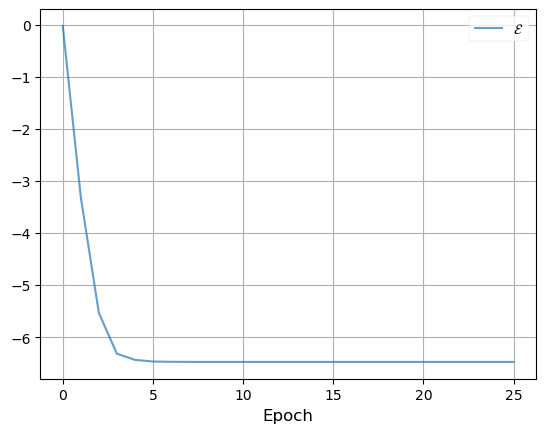

In [24]:
fig, axs = plt.subplots(1, 1)

axs.grid(True)
#axs.set_yscale('log')
axs.set_xlabel('Epoch', fontsize=12)
axs.plot(epochs, losses['total'], "-", alpha=.7, label='$\mathcal{E}$')

#axs.set_xticks(epochs[::25])
axs.legend().get_frame().set_linewidth(0.25)

if save:
    plt.savefig(savedir + 'losses.pdf', bbox_inches ='tight')
plt.show()